In [60]:
import base64
import requests
import numpy as np
from PIL import Image
from io import BytesIO
from typing import List, Tuple
import numpy as np

# === CONFIGURATION ===
rows = 12
cols = 12
final_width = 81
final_height = 61
tile_width = final_width // cols
tile_height = final_height // rows

def mse(img1: Image.Image, img2: Image.Image) -> float:
    """Compute mean squared error between two images."""
    arr1 = np.array(img1).astype("float32")
    arr2 = np.array(img2).astype("float32")
    return np.mean((arr1 - arr2) ** 2)

def split_image_safe(image: Image.Image, rows: int, cols: int, tile_width: int, tile_height: int) -> List[Image.Image]:
    """Safely splits the original image using the fixed tile size, padding if needed."""
    padded_width = tile_width * cols
    padded_height = tile_height * rows
    padded_image = Image.new("RGB", (padded_width, padded_height))
    padded_image.paste(image, (0, 0))

    tiles = []
    for r in range(rows):
        for c in range(cols):
            left = c * tile_width
            upper = r * tile_height
            right = left + tile_width
            lower = upper + tile_height
            tile = padded_image.crop((left, upper, right, lower))
            tiles.append(tile)
    return tiles


def decode_tiles(base64_pieces: List[str]) -> List[Image.Image]:
    return [
        Image.open(BytesIO(base64.b64decode(piece))).convert("RGB")
        for piece in base64_pieces
    ]

def match_tile_order(original_tiles: List[Image.Image], scrambled_tiles: List[Image.Image]) -> List[int]:
    """Return the index in scrambled_tiles that matches each original_tile."""
    order = []
    used = set()

    for orig in original_tiles:
        best_match = None
        best_score = float("inf")
        for i, scr in enumerate(scrambled_tiles):
            if i in used:
                continue
            score = mse(orig, scr)
            if score < best_score:
                best_score = score
                best_match = i
        order.append(best_match)
        used.add(best_match)
    
    return order

def save_reconstructed_image(scrambled_tiles, correct_order, tile_width, tile_height, rows=12, cols=12, filename="reconstructed.jpg"):
    canvas = Image.new("RGB", (tile_width * cols, tile_height * rows))
    for idx, tile_index in enumerate(correct_order):
        row = idx // cols
        col = idx % cols
        tile = scrambled_tiles[tile_index]
        canvas.paste(tile, (col * tile_width, row * tile_height))
    canvas.save(filename)
    print(f"✅ Saved to {filename}")


session = "nLXTKqIpU4Wxlhw0PfBbTI309FoofWjXOfofXXNtks92PQveWm7rMlUCYcR_Hxnzgi0XJRWAA0Dil_K_fqC6ZOIaruVEXuxaO8ARAQIg9XZwLhy4_yjtbQ4jDia4w5cxQxH_WK6bwW-_zOO-fkNUhyuxYJ2K4IveOv01TIgxkeA="
headers = {
    "Cookie": f"session={session}",
}
# --- Fetch Puzzle ---
print(puzzle_data['url'])  # Optionally open full image URL in browser
input("Press Enter after downloading original image as 'original.jpg'...")

puzzle_data = requests.get(f"http://34.55.69.223:14001/api/newpuzzle", headers=headers).json()
scrambled_tiles = decode_tiles(puzzle_data["pieces"])
# --- Extract Metadata ---

ModuleNotFoundError: No module named 'skimage'

In [14]:
puzzle_data.keys()

dict_keys(['title', 'level', 'artist', 'url', 'pieces', 'puzzle_id', 'rows', 'cols', 'width', 'height', 'puzzle_time', 'end_time', 'show_timer'])

In [18]:
puzzle_data['cols']

12

In [3]:
#puzzle_data
scrambled_tiles = decode_tiles(puzzle_data["pieces"])

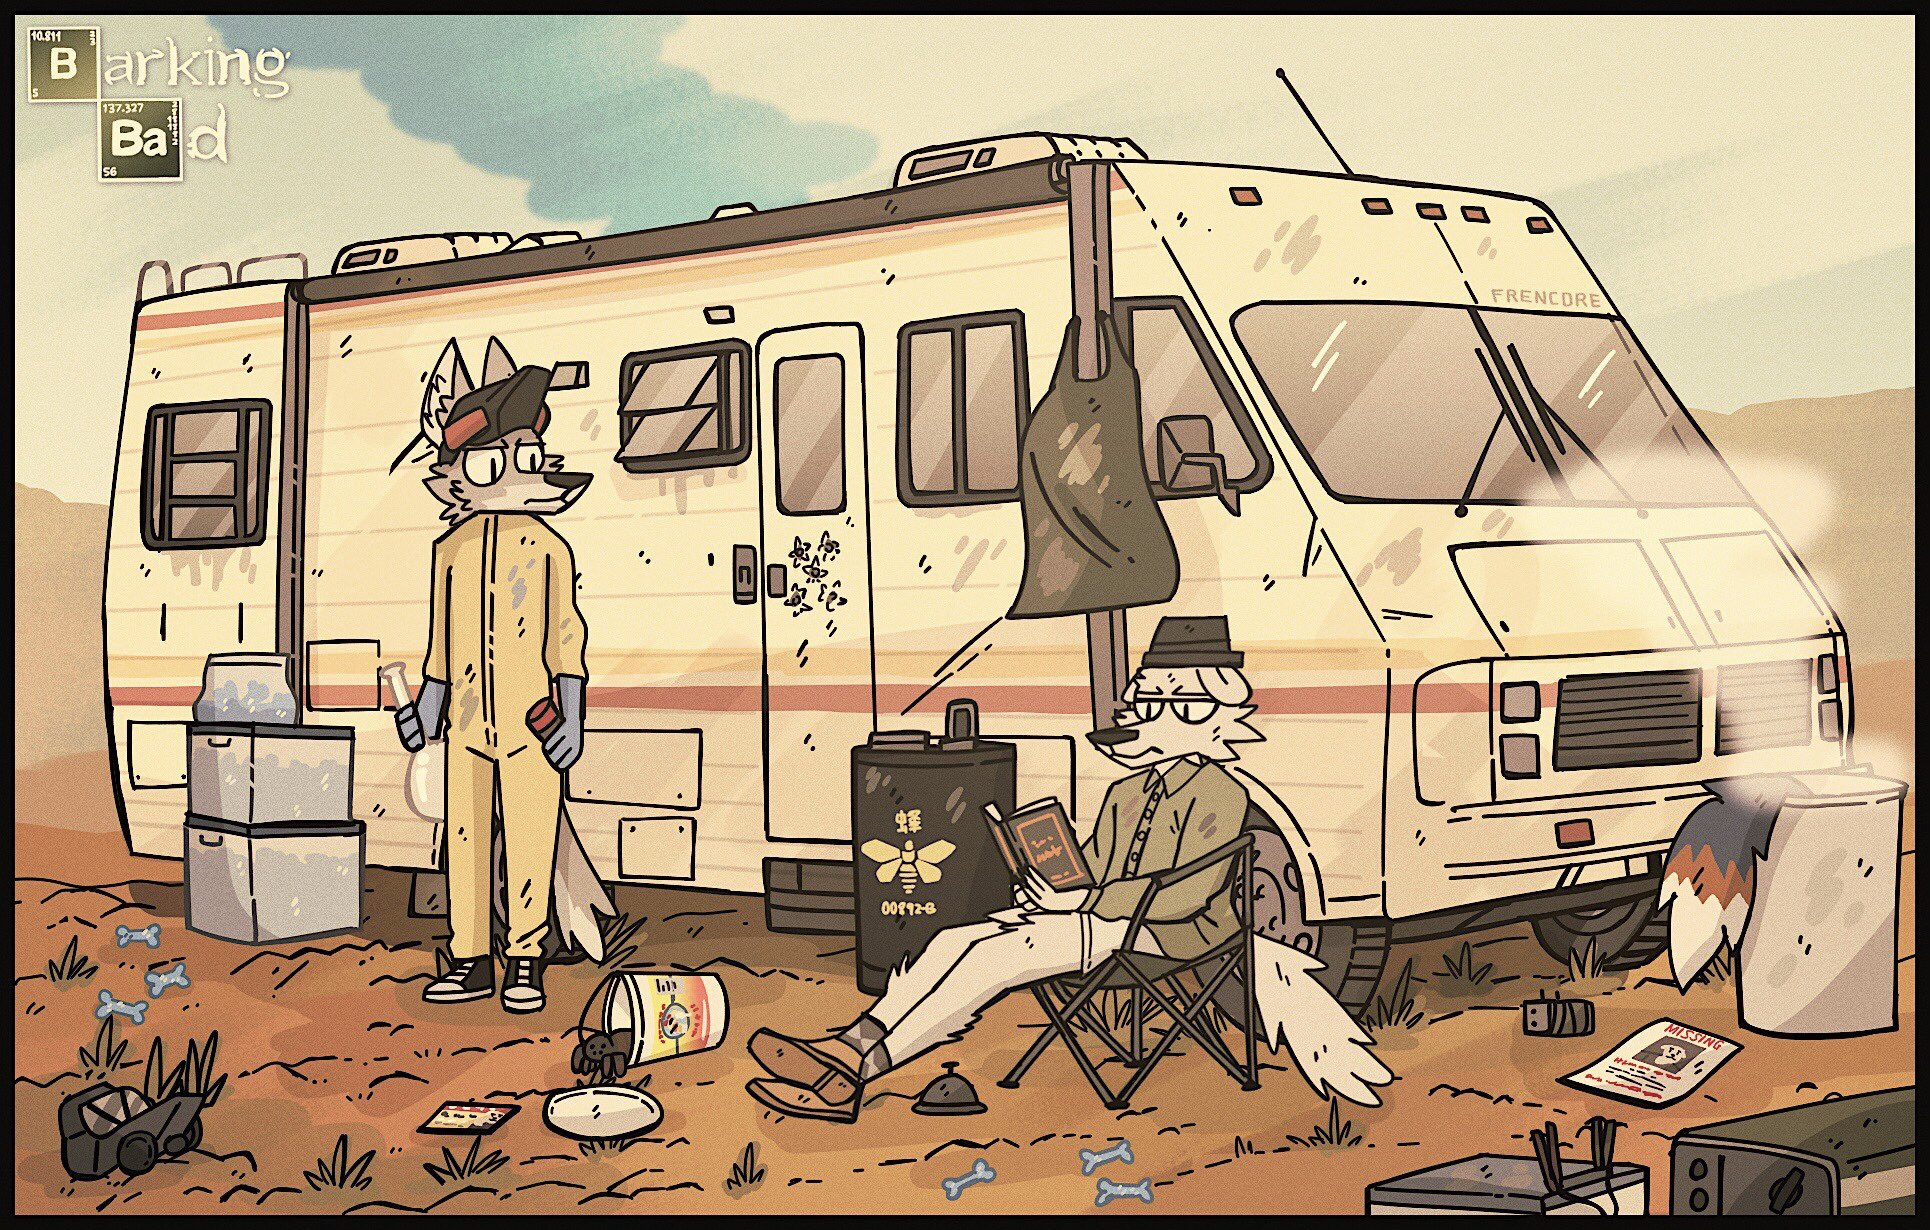

In [20]:
with Image.open('original.jpg') as img:
    display(img)

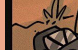

In [94]:
scrambled_tiles[3]

In [39]:
img.size

(1930, 1230)

In [41]:
new_size = tuple([elem*puzzle_data['cols'] for elem in scrambled_tiles[3].size ])

In [102]:
new_img = img.resize(new_size,resample=2)

In [104]:
def find_exact_match(large_img, small_img):
    """Find exact pixel matches of small_img in large_img"""
    large_arr = np.array(large_img)
    small_arr = np.array(small_img)
    
    h, w = small_arr.shape[:2]
    H, W = large_arr.shape[:2]
    print(h , w, H , W)
    matches = []
    
    for y in range(H - h + 1):
        for x in range(W - w + 1):
            section = large_arr[y:y+h, x:x+w]
            if np.array_equal(section, small_arr):
                return(x,y)
    
    return False

In [105]:
from skimage.metrics import structural_similarity as ssim

def find_ssim_matches(large_img, small_img, threshold=0.5, step=(1,1)):
    """Find regions with high structural similarity"""
    large_arr = np.array(large_img.convert('L'))
    small_arr = np.array(small_img.convert('L'))
    
    h, w = small_arr.shape
    H, W = large_arr.shape
    
    matches = []
    best_match = None
    best_score = 0
    
    for y in range(0, H-h, step[0]):
        for x in range(0, W-w, step[1]):
            window = large_arr[y:y+h, x:x+w]
            if window.shape != small_arr.shape:
                continue
            score = ssim(small_arr, window)
            if score >= threshold:
                if score > best_score:
                    best_match = x,y
                    best_score = score
    
    # Sort by best matches
    matches.sort(key=lambda x: x[2], reverse=True)
    return best_match, best_score


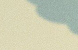

In [97]:
scrambled_tiles[0]

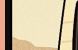

In [101]:
scrambled_tiles[14]

In [107]:
for s_tile in scrambled_tiles:
    res_tile = find_ssim_matches(new_img, s_tile, threshold=0.1)#, step=s_tile.size)
    print(res_tile)

((152, 46), np.float64(0.9089513082238326))


KeyboardInterrupt: 

In [74]:
find_exact_match(new_img,scrambled_tiles[6])

50 78 600 936


False

In [48]:
scrambled_tiles[4].size


(78, 50)

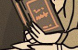

In [19]:
scrambled_tiles[4]

In [ ]:
# --- Load & Process Images ---
print(puzzle_data['url'])  # Optionally open full image URL in browser
input("Press Enter after downloading original image as 'original.jpg'...")

original_image = Image.open("original.jpg").convert("RGB")
scrambled_tiles = decode_tiles(puzzle_data["pieces"])
tile_width, tile_height = scrambled_tiles[0].size
original_tiles = split_image_safe(original_image, rows, cols, tile_width, tile_height)

# --- Match & Reconstruct ---
correct_order = match_tile_order(original_tiles, scrambled_tiles)
save_reconstructed_image(scrambled_tiles, correct_order, tile_width, tile_height)

# --- Submit Answer ---
answer_payload = {
    "puzzle_id": puzzle_data["puzzle_id"],
    "order": correct_order
}
result = requests.post("http://34.55.69.223:14001/api/checkanswer", json=answer_payload, headers=headers).json()
print(result)

https://twitter.com/ashleyloob/status/1504850114010968065
